Yes — your formulation is correct.  

In the **Graded Response Model (GRM)**, the boundary response functions are defined as cumulative probabilities of responding in category \(k\) or higher:

\[
P(X_{ji} \geq k \mid \theta_j, a_i, b_{ik}) 
= \frac{1}{1 + \exp\bigl(-a_i(\theta_j - b_{ik})\bigr)}, \quad k = 1, \ldots, K-1
\]

This is exactly the logistic function applied to the linear predictor \(a_i(\theta_j - b_{ik})\).  

Equivalently, in logit form:

\[
\log\left( 
\frac{P(X_{ji} \geq k \mid \theta_j, a_i, b_{ik})}{1 - P(X_{ji} \geq k \mid \theta_j, a_i, b_{ik})}
\right) = a_i(\theta_j - b_{ik})
\]

---

### How category probabilities are derived
- The probability of being in a specific category \(k\) is obtained by subtracting adjacent cumulative probabilities:
  $$
  P(X_{ji} = k \mid \theta_j) = P(X_{ji} \geq k \mid \theta_j) - P(X_{ji} \geq k+1 \mid \theta_j)
  $$
- For the lowest category (\(k=0\)):
  $$
  P(X_{ji} = 0 \mid \theta_j) = 1 - P(X_{ji} \geq 1 \mid \theta_j)
  $$
- For the highest category (\(k=K-1\)):
  $$
  P(X_{ji} = K-1 \mid \theta_j) = P(X_{ji} \geq K-1 \mid \theta_j)
  $$

---

So the equations you wrote are indeed the standard GRM boundary response functions. They form the foundation for computing the full set of category probabilities.  

Would you like me to also show a **worked example with a 5-point Likert item** (say, thresholds \(b_{i1}, \ldots, b_{i4}\)) so you can see how the subtraction gives the exact probability for each response category?

# Graded Response Model (GRM) — Bayesian Estimation with Stan

## 1. Model Description

The **Graded Response Model** (Samejima, 1969) is a polytomous IRT model for **ordered categorical responses** (e.g., Likert-scale items: Never / Sometimes / Often / Always scored 0–3).

### Cumulative Probabilities

For $K$ ordered categories ($k = 0, 1, \ldots, K{-}1$), the GRM defines **boundary response functions**:

$$
    P(X_{ji} \geq k \mid \theta_j, a_i, b_{ik}) 
        = \text{logistic}\bigl(a_i(\theta_j - b_{ik})\bigr), \quad k = 1, \ldots, K{-}1
$$
or
\begin{align}
    \log\left( 
        \frac{P(X_{ji} \geq k \mid \theta_j, a_i, b_{ik})}{1-P(X_{ji} \geq k \mid \theta_j, a_i, b_{ik})}
    \right)
    & = a_i(\theta_j - b_{ik})
    \\
    & = 
    \log\left( 
        \frac{P(X_{ji} \geq k \mid \theta_j, a_i, b_{ik})}{P(X_{ji} < k \mid \theta_j, a_i, b_{ik})}
    \right)
\end{align}

Category probabilities are obtained by differencing:
  $$
  P(X_{ji} = k \mid \theta_j) = P(X_{ji} \geq k \mid \theta_j) - P(X_{ji} \geq k+1 \mid \theta_j)
  $$
- For the lowest category ($k=0$):
  $$
  P(X_{ji} = 0 \mid \theta_j) = 1 - P(X_{ji} \geq 1 \mid \theta_j)
  $$
- For the highest category ($k=K-1$):
  $$
  P(X_{ji} = K-1 \mid \theta_j) = P(X_{ji} \geq K-1 \mid \theta_j)
  $$

- $P(X_{ji} \geq 0) = 1$ 
- $P(X_{ji} \geq K) = 0$.


**Parameters**
| Parameter | Interpretation |
|-----------|----------------|
| $a_i > 0$ | Item discrimination (shared slope for all boundaries) |
| $b_{i1} < b_{i2} < \cdots < b_{i,K-1}$ | Ordered threshold parameters for item $i$ |

### Key Properties
- Each item has **one discrimination** and **$K-1$ ordered thresholds**.
- Thresholds must satisfy $b_{i1} < b_{i2} < \cdots$ (enforced via the `ordered` type in Stan).
- The model reduces to the 2PL for $K = 2$ categories.

### Priors
$$\theta_j \sim \mathcal{N}(0,1), \quad a_i \sim \text{LogNormal}(0, 0.5), \quad b_{ik} \sim \mathcal{N}(0,2) \text{ (ordered)}$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

77 students, 20 items, **4 ordered categories** (0, 1, 2, 3).

In [2]:
J, I, K = 177, 20, 4   # K = number of categories

theta_true = np.random.normal(0, 1, J)
a_true     = np.exp(np.random.normal(0, 0.5, I))
# More robust threshold generation: enforce min/max gap and resample if needed
b_true = np.zeros((I, K - 1))
min_gap = 0.5
max_gap = 2.5
base_range = (-2, 2)
for i in range(I):
    valid = False
    while not valid:
        base = np.clip(np.random.normal(-1.5, .1), *base_range)
        increments = np.clip(np.abs(np.random.normal(1.0, 0.3, K - 2)) + 0.3, min_gap, max_gap)
        b_true[i, 0] = base
        for k in range(1, K - 1):
            b_true[i, k] = b_true[i, k - 1] + increments[k - 1]
        # Check all gaps
        gaps = np.diff(b_true[i])
        if np.all((gaps >= min_gap) & (gaps <= max_gap)):
            valid = True

def grm_probs(theta, a, b_thresholds):
    """Return category probabilities array of shape (K,) for one person-item pair."""
    cum = np.concatenate([[1.0],
                          [1.0 / (1.0 + np.exp(-a * (theta - bk))) for bk in b_thresholds],
                          [0.0]])
    probs = cum[:-1] - cum[1:]
    probs = np.maximum(probs, 1e-10)
    return probs / probs.sum()

Y = np.zeros((J, I), dtype=int)
for j in range(J):
    for i in range(I):
        pr = grm_probs(theta_true[j], a_true[i], b_true[i])
        Y[j, i] = np.random.choice(K, p=pr)

print(f"Response shape: {Y.shape},  Categories: {np.unique(Y)}")
print(f"Category counts: {np.bincount(Y.ravel())}")


Response shape: (177, 20),  Categories: [0 1 2 3]
Category counts: [814 903 875 948]


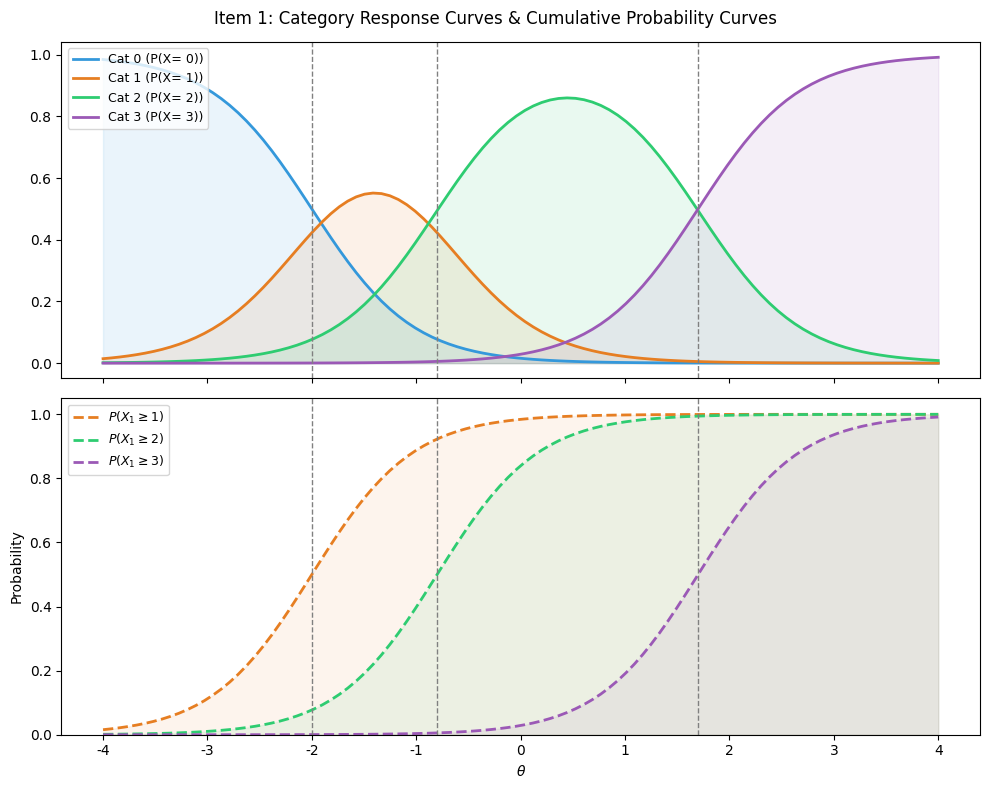

In [3]:
b_true[0] = [-2.0, -.8, 1.7]  # For better visualization of category separation in the first item
theta_range = np.linspace(-4, 4, 100)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(2,1, figsize=(10, 8), sharex=True)
# Plot category response curves (ICCs) for item 1
ax = axes[0]
for k in range(K):
    probs = [grm_probs(t, a_true[0], b_true[0])[k] for t in theta_range]
    ax.plot(theta_range, probs, color=cat_colors[k], linestyle='-', linewidth=2, label=f'Cat {k} (P(X= {k}))')
    ax.fill_between(theta_range, probs, alpha=0.10, color=cat_colors[k])
for bk in b_true[0]:
    ax.axvline(bk, color='gray', linestyle='--', linewidth=1)
ax.legend(fontsize=9, loc='upper left')
# Plot cumulative probability curves for item 1
ax = axes[1]
for k in range(1, K):
    cum_probs = [1.0 / (1.0 + np.exp(-a_true[0] * (t - b_true[0][k-1]))) for t in theta_range]
    ax.plot(theta_range, cum_probs, color=cat_colors[k], linestyle='--', linewidth=2, label=f'$P(X_1 \\geq {k})$')
    ax.fill_between(theta_range, cum_probs, alpha=0.08, color=cat_colors[k])

for bk in b_true[0]:
    ax.axvline(bk, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.suptitle('Item 1: Category Response Curves & Cumulative Probability Curves')
plt.tight_layout()
plt.show()


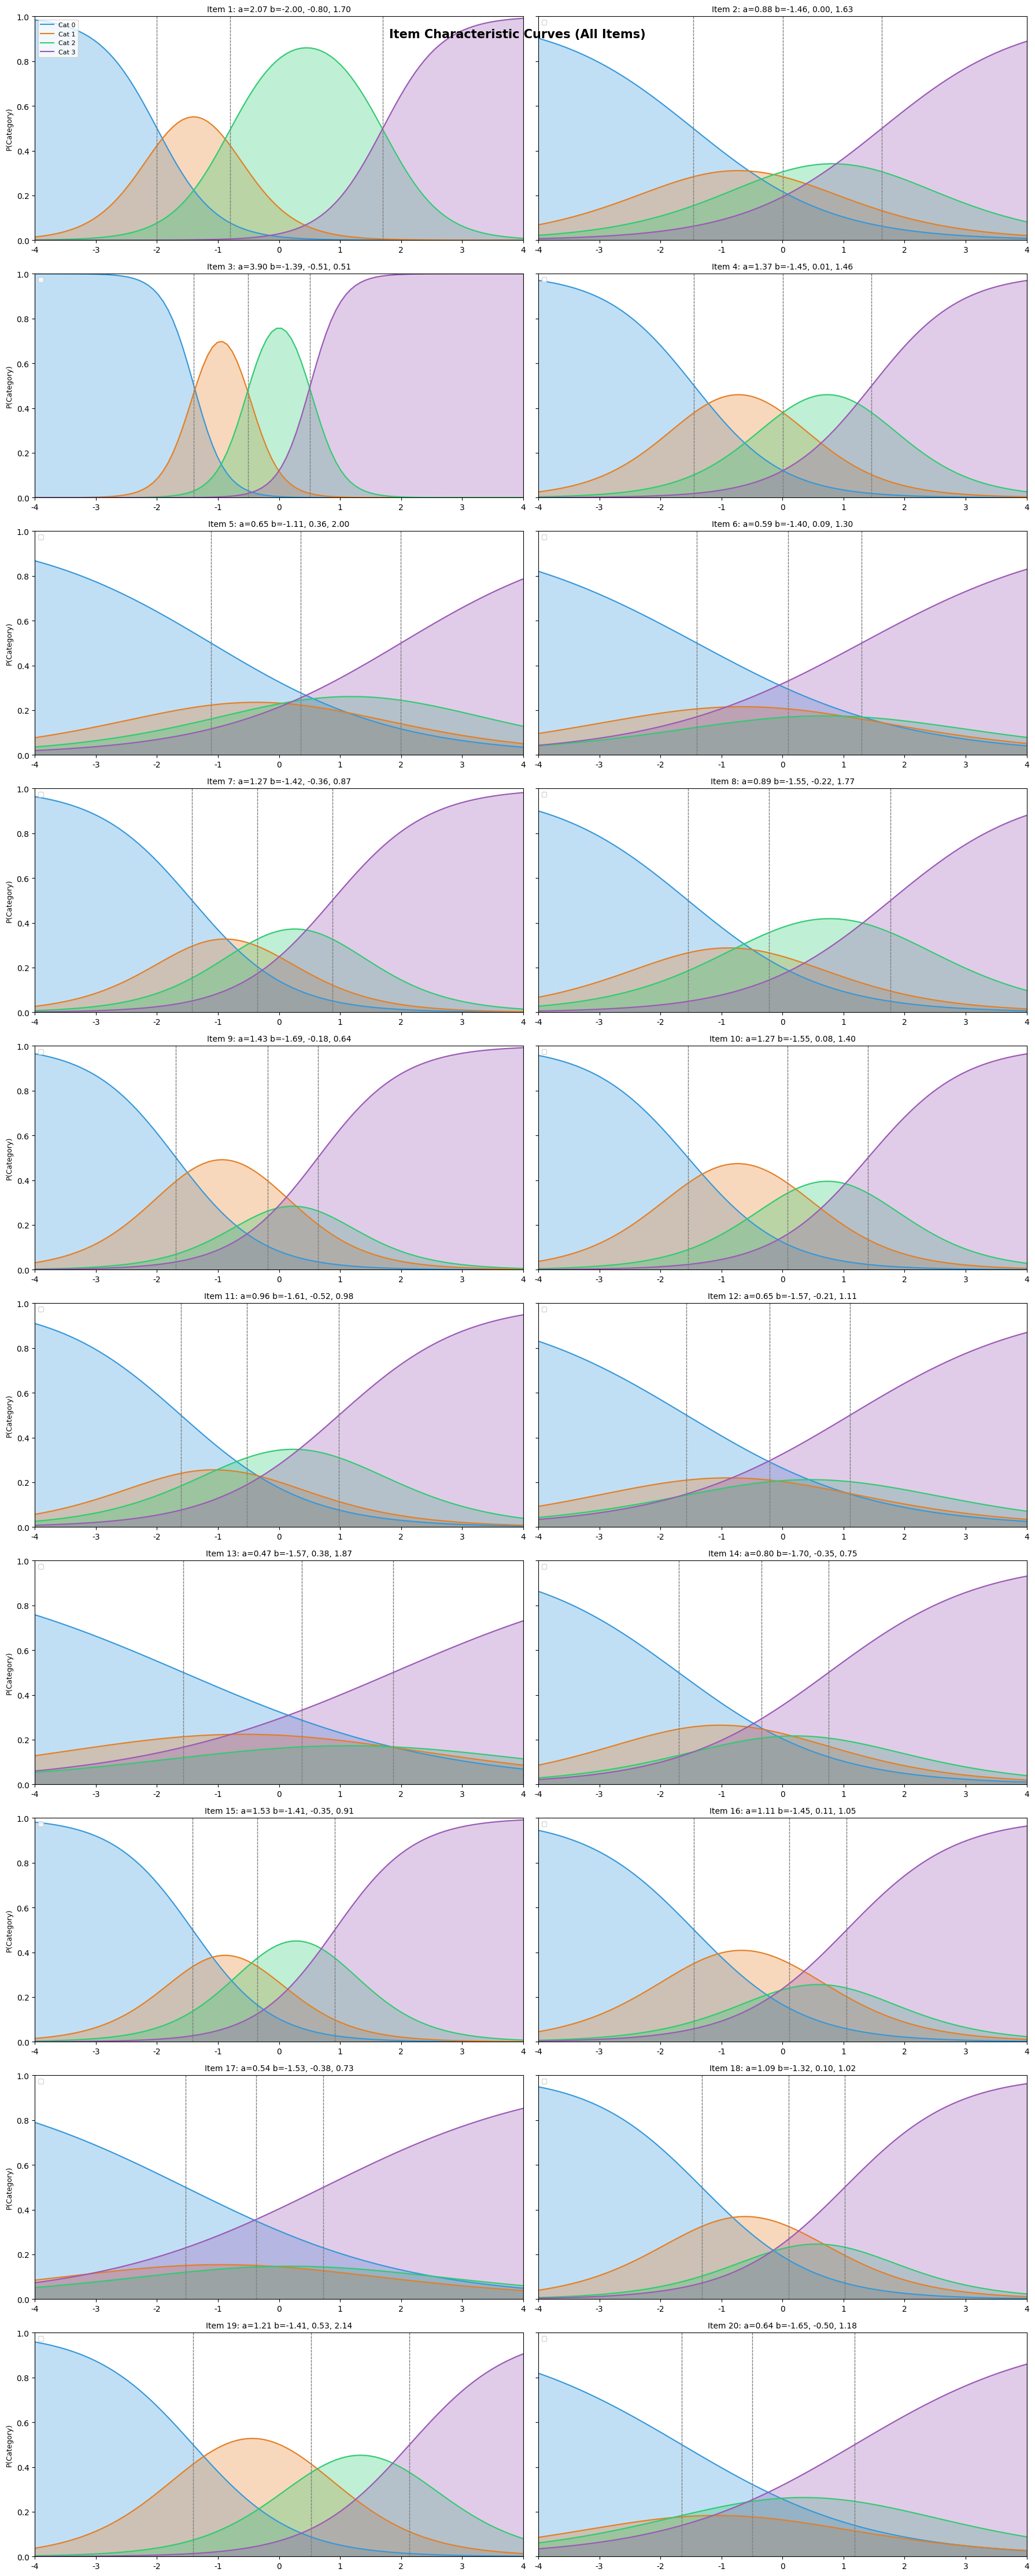

In [4]:
ncols = 2
fig, axes = plt.subplots(I // ncols + int(I % ncols != 0), ncols, figsize=(18, 4.5 * ((I // ncols) + int(I % ncols != 0))), sharey=True)
axes = axes.ravel()
for i in range(I):
    ax = axes[i]
    for k in range(K):
        probs = [grm_probs(t, a_true[i], b_true[i])[k] for t in theta_range]
        ax.plot(theta_range, probs, color=cat_colors[k], linewidth=1.5, label=f'Cat {k}' if i == 0 else None)
        ax.fill_between(theta_range, probs, alpha=0.3, color=cat_colors[k])
        ax.vlines(b_true[i], 0, 1, color='gray', linestyle='--', linewidth=0.8)
    b_str = ', '.join([f'{bk:.2f}' for bk in b_true[i]])
    ax.set_title(f'Item {i+1}: a={a_true[i]:.2f} b={b_str}', fontsize=10)
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='upper left')
    if i % ncols == 0:
        ax.set_ylabel('P(Category)', fontsize=9)
    if i >= (I // ncols) * ncols:
        ax.set_xlabel('$\\theta$', fontsize=9)
for j in range(I, len(axes)):
    axes[j].axis('off')
axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Item Characteristic Curves (All Items)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Stan Model Code

In [5]:
stan_code = """
  data {
    int<lower=1> J;                  // persons
    int<lower=1> I;                  // items
    int<lower=2> K;                  // categories
    int<lower=0> N;                  // responses
    array[N] int<lower=1,upper=J> jj;
    array[N] int<lower=1,upper=I> ii;
    array[N] int<lower=1,upper=K> y; // observed responses
  }
  parameters {
    vector[J] theta;                 // person abilities
    vector<lower=0>[I] a;            // item discriminations
    array[I] ordered[K-1] b;         // item thresholds
  }
  model {
    // priors
    theta ~ normal(0, 1);
    a     ~ lognormal(0, 0.5);
    for (i in 1:I) b[i] ~ normal(0, 2);

    // likelihood using ordered_logistic
    for (n in 1:N) {
      int j = jj[n];
      int i = ii[n];
      // linear predictor: discrimination * ability
      y[n] ~ ordered_logistic(a[i] * theta[j], b[i]);
    }
  }
"""
  
jj_arr, ii_arr, y_arr = [], [], []
for j in range(J):
    for i in range(I):
        jj_arr.append(j + 1); ii_arr.append(i + 1)
        y_arr.append(int(Y[j, i]) + 1)   # 1-indexed for Stan

stan_data = {'J': J, 'I': I, 'K': K, 'N': J * I,
              'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}

tmpdir = tempfile.mkdtemp()
stan_path = os.path.join(tmpdir, 'grm.stan')
with open(stan_path, 'w') as f:
    f.write(stan_code)

model = cmdstanpy.CmdStanModel(stan_file=stan_path)
print('Compiled.')

17:44:19 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\tmp8u94vx8u\grm.stan to exe file C:\Users\yongduek\AppData\Local\Temp\tmp8u94vx8u\grm.exe
17:44:40 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\tmp8u94vx8u\grm.exe


Compiled.


## 4. Bayesian Inference via MCMC

In [6]:
fit = model.sample(
    data=stan_data, chains=4,
    iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
)
print(fit.diagnose())

17:44:41 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

17:49:32 - cmdstanpy - INFO - CmdStan done processing.
17:49:32 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is 7714.82, but should be greater than the previous element, 7714.82 (in 'grm.stan', line 27, column 6 to column 53)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is 25883.9, but should be greater than the previous element, 25883.9 (in 'grm.stan', line 27, column 6 to column 53)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -15.0075, but should be greater than the previous element, -15.0075 (in 'grm.stan', line 27, column 6 to column 53)
	Exception: ordered_logistic: Location parameter is -inf, but must be finite! (in 'grm.stan', line 27, column 6 to column 53)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is 3.01716e+35, but should be greater than th


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [13]:
theta_post = fit.stan_variable('theta')  # shape (4000, J)
a_post     = fit.stan_variable('a')      # shape (4000, I)
b_post     = fit.stan_variable('b')      # shape (4000, I, K-1)
#
theta_est = fit.stan_variable('theta').mean(axis=0)
a_est     = fit.stan_variable('a').mean(axis=0)
b_est     = fit.stan_variable('b').mean(axis=0)   # shape (4000, I, K-1)

print(f"Theta corr: {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
print(f"a     corr: {np.corrcoef(a_true, a_est)[0,1]:.3f}")
print(f"\nThreshold recovery (first 5 items):")
print(f"{'Item':>5} {'b1_t':>7} {'b1_e':>7} {'b2_t':>7} {'b2_e':>7} {'b3_t':>7} {'b3_e':>7}")
for i in range(5):
    print(f"{i+1:>5} {b_true[i,0]:>7.3f} {b_est[i,0]:>7.3f} "
            f"{b_true[i,1]:>7.3f} {b_est[i,1]:>7.3f} "
            f"{b_true[i,2]:>7.3f} {b_est[i,2]:>7.3f}")


Theta corr: 0.943
a     corr: 0.936

Threshold recovery (first 5 items):
 Item    b1_t    b1_e    b2_t    b2_e    b3_t    b3_e
    1  -2.000  -3.210  -0.800  -0.168   1.700   1.736
    2  -1.464  -1.298   0.004   0.127   1.629   1.697
    3  -1.395  -3.867  -0.508  -1.231   0.511   1.680
    4  -1.448  -1.852   0.006   0.025   1.460   1.775
    5  -1.115  -0.635   0.357   0.272   1.997   1.516


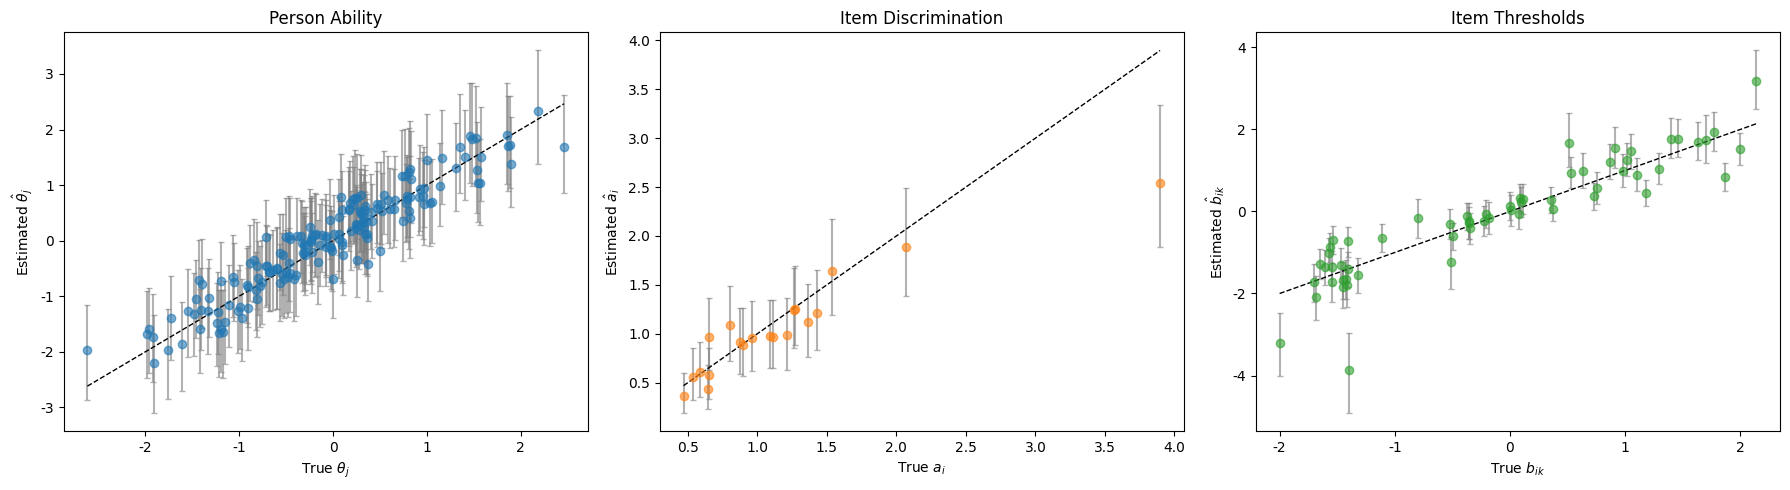

In [ ]:
# Compute 96% credible intervals for each parameter
theta_lower = np.percentile(theta_post, 2, axis=0)
theta_upper = np.percentile(theta_post, 98, axis=0)

a_lower = np.percentile(a_post, 2, axis=0)
a_upper = np.percentile(a_post, 98, axis=0)

b_lower = np.percentile(b_post, 2, axis=0)
b_upper = np.percentile(b_post, 98, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# theta
axes[0].errorbar(theta_true, theta_est, 
                 yerr=[theta_est - theta_lower, theta_upper - theta_est], 
                 fmt='o', alpha=0.6, color='C0', ecolor='gray', capsize=2)
axes[0].plot([theta_true.min(), theta_true.max()], [theta_true.min(), theta_true.max()], 'k--', lw=1)
axes[0].set_xlabel('True $\\theta_j$')
axes[0].set_ylabel('Estimated $\\hat{\\theta}_j$')
axes[0].set_title('Person Ability')

# a
axes[1].errorbar(a_true, a_est, 
                 yerr=[a_est - a_lower, a_upper - a_est], 
                 fmt='o', alpha=0.6, color='C1', ecolor='gray', capsize=2)
axes[1].plot([a_true.min(), a_true.max()], [a_true.min(), a_true.max()], 'k--', lw=1)
axes[1].set_xlabel('True $a_i$')
axes[1].set_ylabel('Estimated $\\hat{a}_i$')
axes[1].set_title('Item Discrimination')

# b (flattened for all thresholds)
axes[2].errorbar(b_true.ravel(), b_est.ravel(), 
                 yerr=[b_est.ravel() - b_lower.ravel(), b_upper.ravel() - b_est.ravel()], 
                 fmt='o', alpha=0.6, color='C2', ecolor='gray', capsize=2)
axes[2].plot([b_true.min(), b_true.max()], [b_true.min(), b_true.max()], 'k--', lw=1)
axes[2].set_xlabel('True $b_{ik}$')
axes[2].set_ylabel('Estimated $\\hat{b}_{ik}$')
axes[2].set_title('Item Thresholds')

plt.tight_layout()
plt.show()

## 5. Visualizations

### 5a. Wright Map

For polytomous models, the Wright map includes **threshold locations** for each item rather than single difficulty values. Each item $i$ contributes $K-1 = 3$ marks to the item panel, one per threshold $b_{ik}$.

**Interpretation**: The thresholds $b_{i1}, b_{i2}, b_{i3}$ are the ability values at which it becomes more likely to score $\geq 1$, $\geq 2$, $\geq 3$ respectively. Well-spaced thresholds indicate an item that effectively discriminates across the full ability range. Clustered thresholds mean a narrow range of ability is needed to move through all categories.

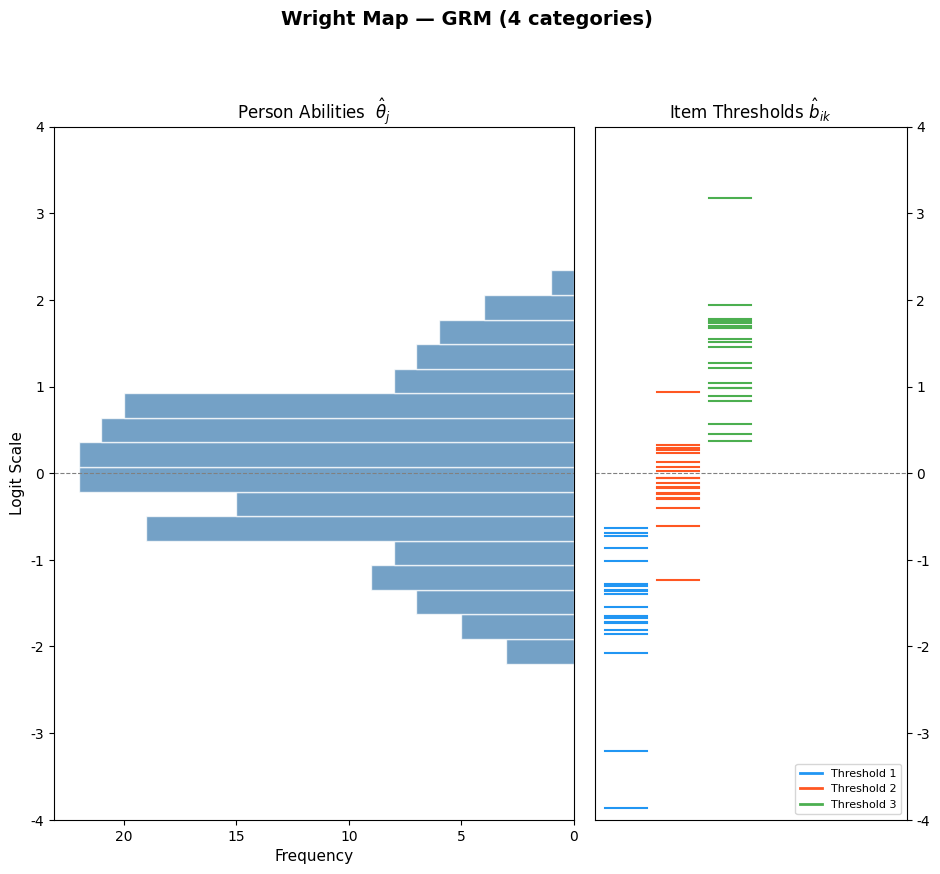

In [8]:
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1.5], wspace=0.05)
ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])
y_lim = (-4, 4)
threshold_colors = ['#2196F3', '#FF5722', '#4CAF50']

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Person Abilities  $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

for i in range(I):
    for k in range(K - 1):
        bv = b_est[i, k]
        ax_i.plot([0.05 + k * 0.25, 0.25 + k * 0.25], [bv, bv],
                  color=threshold_colors[k], linewidth=1.5)
ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 1.5); ax_i.set_xticks([])
ax_i.set_yticks(range(-4, 5)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('Item Thresholds $\\hat{b}_{ik}$', fontsize=12)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)
for k in range(K - 1):
    ax_i.plot([], [], color=threshold_colors[k], linewidth=2, label=f'Threshold {k+1}')
ax_i.legend(loc='lower right', fontsize=8)

fig.suptitle('Wright Map — GRM (4 categories)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_grm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5b. Category Response Curves (CRC) / Item Characteristic Curves

For polytomous models, each item produces $K$ **category response curves** $P(X_i = k \mid \theta)$ for $k = 0, 1, \ldots, K{-}1$.

**Interpretation**:
- Each coloured band shows the probability of selecting a specific category at each ability level.
- **Low ability** persons are most likely to choose category 0; **high ability** persons choose category $K{-}1 = 3$.
- The **mode** of each curve (its peak) shows the ability level where that response is the modal choice.
- Narrow peaks indicate that a category is only the modal choice over a short ability range, meaning it contributes little information.
- The plot panel below shows ICCs for the first 4 items for clarity.

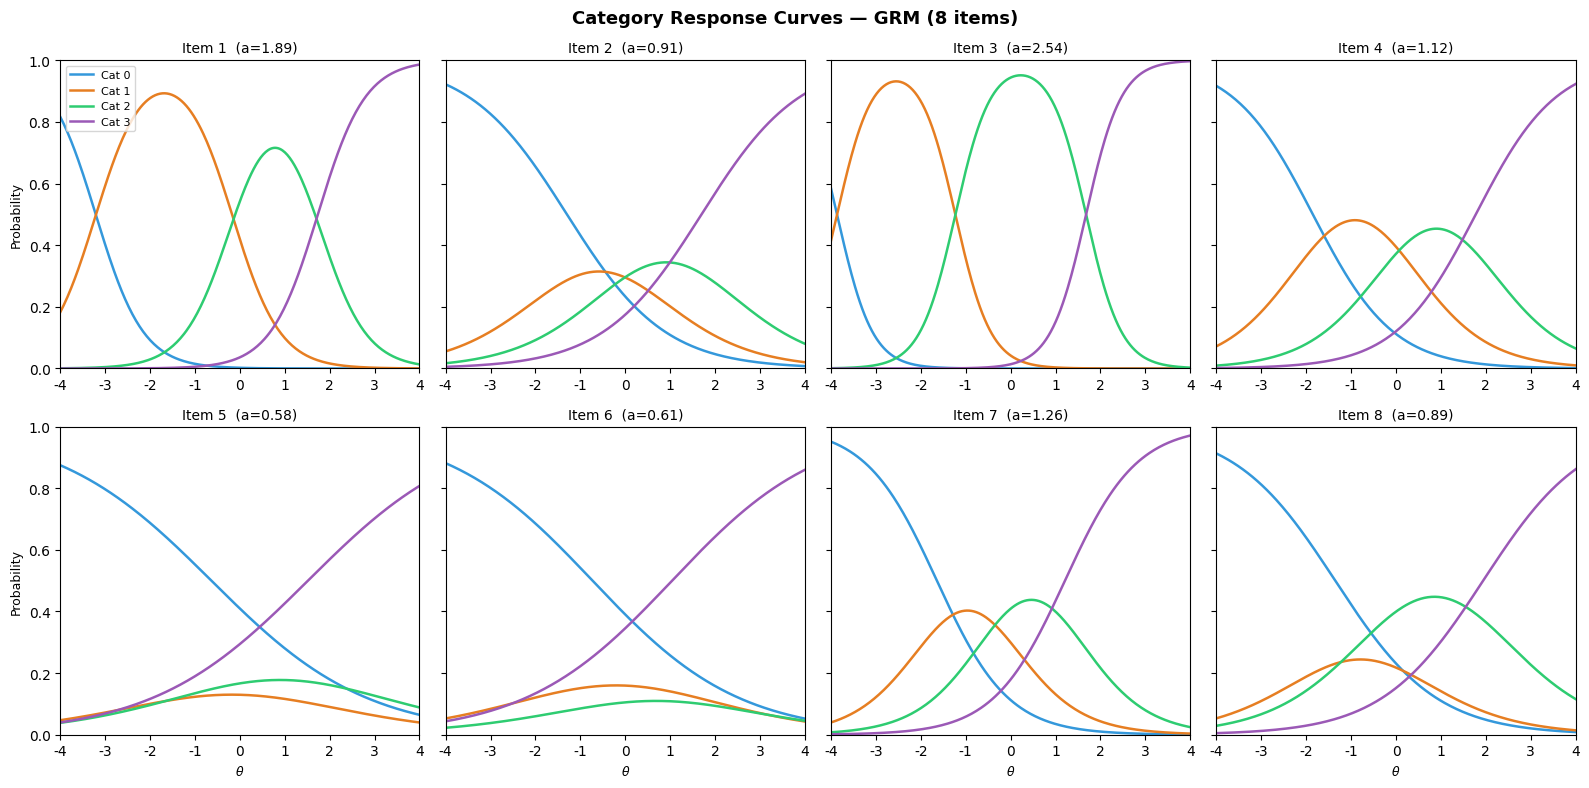

In [9]:
theta_range = np.linspace(-4, 4, 300)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for idx, i in enumerate(range(min(8, I))):
    ax = axes[idx]
    for k in range(K):
        probs = [grm_probs(t, a_est[i], b_est[i])[k] for t in theta_range]
        ax.plot(theta_range, probs, color=cat_colors[k], linewidth=1.8,
                label=f'Cat {k}')
    ax.set_title(f'Item {i+1}  (a={a_est[i]:.2f})', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    if idx >= 4: ax.set_xlabel('$\\theta$', fontsize=9)
    if idx in [0, 4]: ax.set_ylabel('Probability', fontsize=9)

axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Category Response Curves — GRM (8 items)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'crc_grm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5c. Test Characteristic Curve (TCC)

$$\text{TCC}(\theta) = \sum_{i=1}^{I} \mathbb{E}[X_i \mid \theta] = \sum_{i=1}^{I} \sum_{k=0}^{K-1} k \cdot P(X_i = k \mid \theta)$$

**Interpretation**: The TCC now maps $\theta$ to the expected total score on the polytomous scale (0 to $I \times (K{-}1) = 60$). The shape reveals how well the test differentiates ability levels: steeper sections indicate larger information; plateaus indicate lower precision for that ability range. The midpoint of the TCC corresponds roughly to the average threshold location.

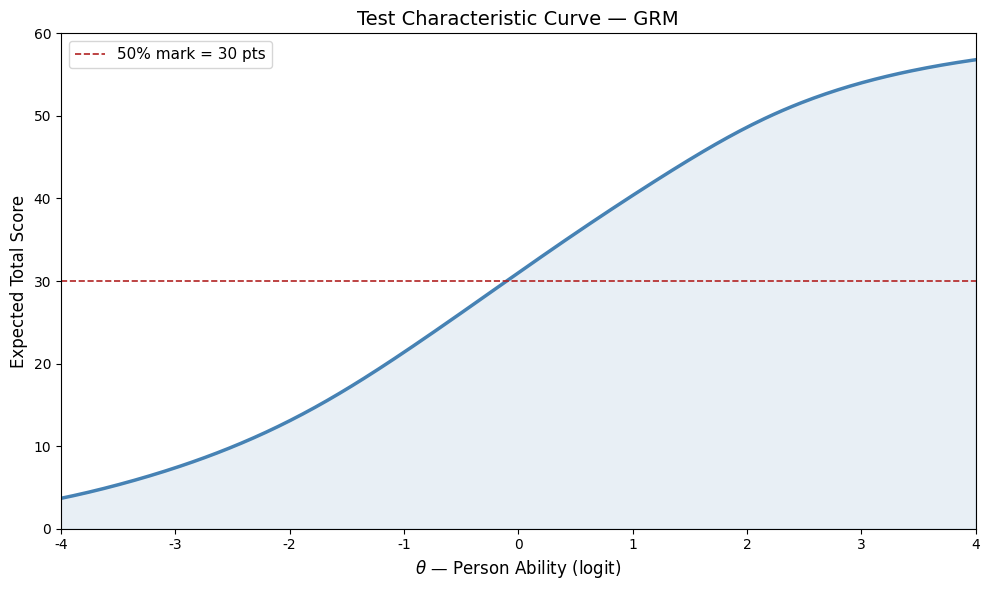

In [10]:
expected_score = np.zeros(len(theta_range))
for i in range(I):
    for t_idx, t in enumerate(theta_range):
        pr = grm_probs(t, a_est[i], b_est[i])
        expected_score[t_idx] += np.dot(np.arange(K), pr)

max_score = I * (K - 1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_range, expected_score, color='steelblue', linewidth=2.5)
ax.fill_between(theta_range, 0, expected_score, alpha=0.12, color='steelblue')
ax.axhline(max_score / 2, color='firebrick', linestyle='--', linewidth=1.2,
           label=f'50% mark = {max_score//2} pts')
ax.set_xlabel('$\\theta$ — Person Ability (logit)', fontsize=12)
ax.set_ylabel('Expected Total Score', fontsize=12)
ax.set_title('Test Characteristic Curve — GRM', fontsize=14)
ax.set_xlim(-4, 4); ax.set_ylim(0, max_score); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'tcc_grm.png'), dpi=120, bbox_inches='tight')
plt.show()

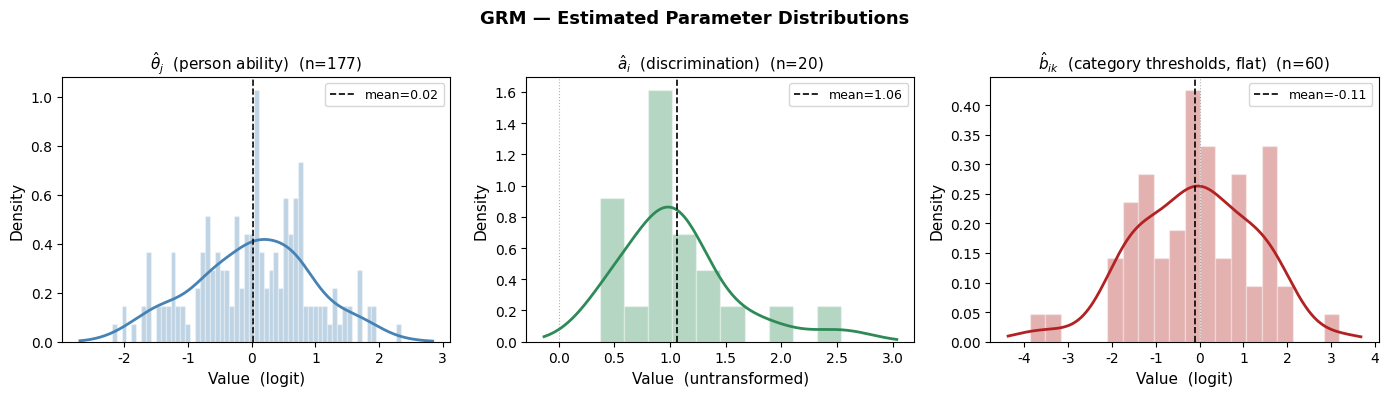

theta     : mean=0.024  SD=0.917  range=[-2.20, 2.34]
a         : mean=1.060  SD=0.497  range=[0.37, 2.54]
b (flat)  : mean=-0.106  SD=1.348  range=[-3.87, 3.18]


In [11]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('GRM — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

b_flat = b_est.ravel()

panels = [
    (axes[0], theta_est, r'$\hat{\theta}_j$  (person ability)',         'steelblue',  'logit'),
    (axes[1], a_est,     r'$\hat{a}_i$  (discrimination)',               'seagreen',   'untransformed'),
    (axes[2], b_flat,    r'$\hat{b}_{ik}$  (category thresholds, flat)', 'firebrick',  'logit'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=max(10, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel(f'Value  ({unit})', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_grm.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('a', a_est), ('b (flat)', b_flat)]:
    print(f"{name:10s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
